# LLM-as-a-Judge Pipeline

Clasificación de preguntas SOCE como **ACUSATORIA / NO_ACUSATORIA** usando few-shot prompting con **o4-mini** y **reasoning_effort=medium**.

## 1. Imports y configuración

In [11]:
import os
import json
import asyncio
import random
import hashlib
import time
import re
from pathlib import Path
import pandas as pd
import numpy as np
from openai import AsyncOpenAI, RateLimitError
from tenacity import retry, stop_after_attempt, retry_if_exception_type, RetryCallState
from tenacity.wait import wait_base
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix
)
from dotenv import load_dotenv, find_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

_env_path = find_dotenv(usecwd=True)
if not _env_path:
    raise FileNotFoundError(
        "No se encontró .env. Crea llm_judge_project/.env con OPENAI_API_KEY=sk-..."
    )
load_dotenv(_env_path)


def _detect_project_root() -> Path:
    """Localiza la raíz del proyecto desde el cwd actual o un cwd padre."""
    candidates = []
    cwd = Path.cwd()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([base / 'tesis' / 'entregable_2' / 'llm_judge_project' for base in [cwd, *cwd.parents]])

    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except FileNotFoundError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / 'data' / 'raw').exists() and (resolved / 'prompts').exists():
            return resolved

    raise FileNotFoundError(
        'No se pudo detectar la raíz de llm_judge_project. '
        'Ejecuta la notebook desde el proyecto o ajusta el detector.'
    )


PROJECT_ROOT = _detect_project_root()
client = AsyncOpenAI(api_key=os.getenv('OPENAI_API_KEY'))

SEMAPHORE = asyncio.Semaphore(5)
RANDOM_STATE = 2026
MODEL = 'o4-mini'  # o4-mini | o4-mini-2024-08-06 | o4-mini-2024-09-10
REASONING_EFFORT = 'medium'   # low | medium | high

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_SPLITS = PROJECT_ROOT / 'data' / 'splits'
DATA_RESULTS = PROJECT_ROOT / 'data' / 'results'
ITER_LOGS = DATA_RESULTS / 'iteration_logs'
FINAL_EVAL = DATA_RESULTS / 'final_evaluation'
PROMPTS_DIR = PROJECT_ROOT / 'prompts'
CACHE_FILE = DATA_RESULTS / 'cache' / 'response_cache.json'

for folder in (DATA_SPLITS, DATA_RESULTS, ITER_LOGS, FINAL_EVAL, PROMPTS_DIR, CACHE_FILE.parent):
    folder.mkdir(parents=True, exist_ok=True)

# Cargar caché desde disco (persiste entre reinicios del kernel)
if CACHE_FILE.exists():
    try:
        with open(CACHE_FILE, encoding='utf-8') as f:
            response_cache: dict = json.load(f)
    except json.JSONDecodeError:
        response_cache = {}
        print(f'Advertencia: {CACHE_FILE.name} estaba corrupto; se reinició la caché.')
    else:
        print(f'Caché cargado desde disco: {len(response_cache)} entradas')
else:
    response_cache: dict = {}
    print('Caché iniciado vacío')

print(f'PROJECT_ROOT: {PROJECT_ROOT.resolve()}')
print(f'API key presente: {bool(os.getenv("OPENAI_API_KEY"))}')
print(f'Concurrencia: {SEMAPHORE._value} requests simultáneas')
print(f'Modelo: {MODEL}  |  Reasoning effort: {REASONING_EFFORT}')
print(f'RANDOM_STATE: {RANDOM_STATE}')


Caché cargado desde disco: 2979 entradas
PROJECT_ROOT: C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project
API key presente: True
Concurrencia: 5 requests simultáneas
Modelo: o4-mini  |  Reasoning effort: medium
RANDOM_STATE: 2026


## 2. Carga y exploración del dataset

In [12]:
def _load_raw_dataset(data_dir: Path) -> tuple[pd.DataFrame, Path]:
    files = sorted(data_dir.glob('*.xlsx')) + sorted(data_dir.glob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No hay dataset en {data_dir}')

    data_path = files[0]
    if data_path.suffix.lower() == '.xlsx':
        df = pd.read_excel(data_path)
    else:
        df = pd.read_csv(data_path)
    return df, data_path


df_raw, dataset_path = _load_raw_dataset(DATA_RAW)
print(f'Dataset cargado: {dataset_path.name}')

# Renombrar columna de etiqueta si viene del dataset Roh López
if 'final_pregunta_isAcusatoria' in df_raw.columns:
    df_raw = df_raw.rename(columns={'final_pregunta_isAcusatoria': 'etiqueta'})

required_columns = {'pregunta', 'etiqueta'}
missing = required_columns - set(df_raw.columns)
if missing:
    raise KeyError(f'Faltan columnas requeridas: {sorted(missing)}')

df_raw['etiqueta'] = pd.to_numeric(df_raw['etiqueta'], errors='raise').astype(int)

print(f'\nTotal preguntas: {len(df_raw)}')
print('\nDistribución de clases:')
dist = df_raw['etiqueta'].value_counts(normalize=True).rename({0: 'No acusatoria', 1: 'Acusatoria'})
print(dist.round(4))
display(df_raw[['pregunta', 'etiqueta']].head())


Dataset cargado: dataset_roh_5005.xlsx

Total preguntas: 5005

Distribución de clases:
etiqueta
No acusatoria    0.9706
Acusatoria       0.0294
Name: proportion, dtype: float64


,pregunta,etiqueta
0,Por favor requerimos se entregue un diagrama d...,0
1,Indique de manera detallada y de manera taxati...,0
2,4.En el punto 6 Información que dispone la ent...,0
3,Se puede ofertar un equipo que utilice cubetas...,0
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0


## 3. Partición estratificada

Split fijo con `random_state=2026`. **No modificar** una vez generado.

In [13]:
# 80/20 global
print(f'RANDOM_STATE: {RANDOM_STATE}')

train_80, test_20 = train_test_split(
    df_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=df_raw['etiqueta']
)

# 75/25 dentro del 80%
train_inner, val_inner = train_test_split(
    train_80, test_size=0.25, random_state=RANDOM_STATE, stratify=train_80['etiqueta']
)

DATA_SPLITS.mkdir(parents=True, exist_ok=True)
train_80.to_csv(DATA_SPLITS / "train_80.csv",       index=False)
test_20.to_csv(DATA_SPLITS / "test_20.csv",         index=False)
train_inner.to_csv(DATA_SPLITS / "train_inner.csv", index=False)
val_inner.to_csv(DATA_SPLITS / "val_inner.csv",     index=False)

for name, df in [("train_80", train_80), ("test_20", test_20),
                 ("train_inner", train_inner), ("val_inner", val_inner)]:
    pct = df['etiqueta'].mean() * 100
    print(f"{name:<12}: {len(df):>5} preguntas | acusatorias: {df['etiqueta'].sum():>3} ({pct:.2f}%)")

RANDOM_STATE: 2026
train_80    :  4004 preguntas | acusatorias: 118 (2.95%)
test_20     :  1001 preguntas | acusatorias:  29 (2.90%)
train_inner :  3003 preguntas | acusatorias:  88 (2.93%)
val_inner   :  1001 preguntas | acusatorias:  30 (3.00%)


In [14]:
# Subconjunto estratificado para refinamiento rápido
# Ajusta VAL_DEV_FRAC para controlar el tamaño:
#   0.05 →  ~50 preguntas   (muy rápido, solo orientativo)
#   0.20 → ~200 preguntas   (rápido, buena señal)
#   1.00 → 1001 preguntas   (completo, igual a val_inner)
VAL_DEV_FRAC = 1

def _sample_stratified_fraction(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    parts = []
    for _, group in df.groupby('etiqueta'):
        n = max(1, int(round(len(group) * frac)))
        n = min(n, len(group))
        parts.append(group.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


val_dev = _sample_stratified_fraction(val_inner, frac=VAL_DEV_FRAC, seed=RANDOM_STATE)

print(f"val_dev  : {len(val_dev):>4} preguntas | acusatorias: {val_dev['etiqueta'].sum():>2} ({val_dev['etiqueta'].mean()*100:.2f}%)")
print(f"val_inner: {len(val_inner):>4} preguntas | acusatorias: {val_inner['etiqueta'].sum():>2} ({val_inner['etiqueta'].mean()*100:.2f}%)")
print(f'\n-> val_dev={len(val_dev)} preguntas (VAL_DEV_FRAC={VAL_DEV_FRAC}). Cambia VAL_DEV_FRAC para ajustar el tamaño.')


val_dev  : 1001 preguntas | acusatorias: 30 (3.00%)
val_inner: 1001 preguntas | acusatorias: 30 (3.00%)

-> val_dev=1001 preguntas (VAL_DEV_FRAC=1). Cambia VAL_DEV_FRAC para ajustar el tamaño.


## 4. Funciones utilitarias

In [15]:
def sample_few_shot_examples(train_df: pd.DataFrame, n: int = 4, seed: int = 42):
    """Muestrea n ejemplos acusatorios y n no acusatorios de train_df."""
    acus_df = train_df[train_df['etiqueta'] == 1]
    no_acus_df = train_df[train_df['etiqueta'] == 0]

    if acus_df.empty or no_acus_df.empty:
        raise ValueError('train_df debe contener ambas clases para few-shot prompting.')

    n_acus = min(n, len(acus_df))
    n_no_acus = min(n, len(no_acus_df))
    acus = acus_df.sample(n=n_acus, random_state=seed)['pregunta'].tolist()
    no_acus = no_acus_df.sample(n=n_no_acus, random_state=seed)['pregunta'].tolist()
    return acus, no_acus


def build_prompt(template: str, acus: list, no_acus: list, pregunta: str) -> str:
    """Rellena los placeholders del template con los ejemplos y la pregunta."""
    p = template
    for i, ej in enumerate(acus, 1):
        p = p.replace(f'{{ejemplo_acusatoria_{i}}}', ej)
    for i, ej in enumerate(no_acus, 1):
        p = p.replace(f'{{ejemplo_no_acusatoria_{i}}}', ej)
    return p.replace('{pregunta}', pregunta)


def parse_response(text: str) -> int:
    """Convierte respuesta del LLM a etiqueta binaria. -1 si no parseable."""
    t = (text or '').strip().upper()
    if 'NO_ACUSATORIA' in t or 'NO ACUSATORIA' in t:
        return 0
    if 'ACUSATORIA' in t:
        return 1
    return -1


print('Funciones utilitarias definidas.')


Funciones utilitarias definidas.


## 5. Cliente LLM asíncrono

In [16]:
_cache_write_counter = 0
_CACHE_FLUSH_EVERY = 10  # escribe a disco cada N respuestas nuevas
_RE_RETRY = re.compile(r'try again in ([\d.]+)s', re.IGNORECASE)


def _cache_key(prompt: str) -> str:
    return hashlib.md5(f'{MODEL}:{REASONING_EFFORT}:{prompt}'.encode()).hexdigest()


def _flush_cache() -> None:
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(response_cache, f, ensure_ascii=False, indent=2)


class _WaitRetryAfter(wait_base):
    """Respeta el retry-after de OpenAI con jitter para evitar thundering herd."""

    def __call__(self, retry_state: RetryCallState) -> float:
        exc = retry_state.outcome.exception()
        if isinstance(exc, RateLimitError):
            base: float | None = None
            resp = getattr(exc, 'response', None)
            if resp is not None:
                after = resp.headers.get('retry-after')
                if after:
                    try:
                        base = max(1.0, float(after))
                    except ValueError:
                        pass
            if base is None:
                m = _RE_RETRY.search(str(exc))
                if m:
                    base = max(1.0, float(m.group(1)))
            if base is not None:
                return base + random.uniform(0.0, base)  # jitter 0-100%
        return 60.0 + random.uniform(0.0, 30.0)


@retry(
    retry=retry_if_exception_type(RateLimitError),
    stop=stop_after_attempt(15),
    wait=_WaitRetryAfter(),
    reraise=True,
)
async def classify_question(prompt: str) -> str:
    """Llama a o4-mini con reasoning_effort medium y caché persistente. Reintenta en RateLimitError."""
    global _cache_write_counter
    cache_key = _cache_key(prompt)
    if cache_key in response_cache:
        return response_cache[cache_key]

    async with SEMAPHORE:
        response = await client.chat.completions.create(
            model=MODEL,
            reasoning_effort=REASONING_EFFORT,
            max_completion_tokens=2000,
            messages=[{'role': 'user', 'content': prompt}],
        )

    result = response.choices[0].message.content or ''
    response_cache[cache_key] = result

    _cache_write_counter += 1
    if _cache_write_counter % _CACHE_FLUSH_EVERY == 0:
        _flush_cache()

    return result


async def classify_batch(prompts: list[str]) -> list[str]:
    """Clasifica en paralelo con barra de progreso compatible con VSCode."""
    total = len(prompts)
    cached = sum(1 for p in prompts if _cache_key(p) in response_cache)
    print(
        f'Clasificando {total} preguntas con {MODEL} (reasoning_effort={REASONING_EFFORT}) '
        f'({cached} en caché, {total - cached} llamadas nuevas)...'
    )

    results = [None] * total
    futures = {asyncio.create_task(classify_question(p)): i for i, p in enumerate(prompts)}

    with tqdm(total=total, desc='Clasificando', unit='preg') as pbar:
        pending = set(futures.keys())
        while pending:
            done, pending = await asyncio.wait(pending, return_when=asyncio.FIRST_COMPLETED)
            for fut in done:
                idx = futures[fut]
                try:
                    results[idx] = fut.result()
                except Exception as e:
                    print(f'\n  Error en pregunta {idx}: {e}')
                    results[idx] = ''
                pbar.update(1)

    _flush_cache()
    print(f'Completado: {total} respuestas | caché en disco: {len(response_cache)} entradas')
    return results


print(f'Cliente LLM asíncrono definido ({MODEL}, reasoning_effort={REASONING_EFFORT}, caché persistente).')


Cliente LLM asíncrono definido (o4-mini, reasoning_effort=medium, caché persistente).


In [7]:
async def run_iteration(
    iteration_num: int,
    prompt_template: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    seed: int = 42,
) -> dict:
    """Ejecuta una iteración completa y guarda predicciones/métricas en disco."""
    if val_df.empty:
        raise ValueError('val_df no puede estar vacío.')

    start = time.perf_counter()
    ITER_LOGS.mkdir(parents=True, exist_ok=True)

    acus_ex, no_acus_ex = sample_few_shot_examples(train_df, n=4, seed=seed)
    prompts = [
        build_prompt(prompt_template, acus_ex, no_acus_ex, pregunta)
        for pregunta in val_df['pregunta'].tolist()
    ]

    raw_predictions = await classify_batch(prompts)

    eval_df = val_df.copy().reset_index(drop=True)
    eval_df['respuesta_llm'] = raw_predictions
    eval_df['prediccion'] = [parse_response(r) for r in raw_predictions]

    preds_path = ITER_LOGS / f'iter_{iteration_num:02d}_preds.csv'
    eval_df.to_csv(preds_path, index=False)

    valid_df = eval_df[eval_df['prediccion'] != -1].copy()
    if valid_df.empty:
        raise ValueError(f'La iteración {iteration_num} no produjo predicciones válidas.')

    y_true = valid_df['etiqueta'].astype(int).to_numpy()
    y_pred = valid_df['prediccion'].astype(int).to_numpy()
    elapsed_s = round(time.perf_counter() - start, 2)

    metrics = {
        'iteration': iteration_num,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'fn': int(((y_true == 1) & (y_pred == 0)).sum()),
        'fp': int(((y_true == 0) & (y_pred == 1)).sum()),
        'elapsed_s': elapsed_s,
        'n_total': int(len(eval_df)),
        'n_valid': int(len(valid_df)),
        'n_invalid': int(len(eval_df) - len(valid_df)),
    }

    log_path = ITER_LOGS / 'iterations_log.csv'
    current_log = pd.DataFrame([metrics])
    if log_path.exists():
        previous_log = pd.read_csv(log_path)
        previous_log = previous_log[previous_log['iteration'] != iteration_num]
        current_log = pd.concat([previous_log, current_log], ignore_index=True)

    current_log.sort_values('iteration').to_csv(log_path, index=False)

    print(
        f"Iteración {iteration_num:02d} | F1={metrics['f1']:.4f} | "
        f"Recall={metrics['recall']:.4f} | Precision={metrics['precision']:.4f} | "
        f"Accuracy={metrics['accuracy']:.4f} | FN={metrics['fn']} | FP={metrics['fp']} | "
        f"Tiempo={elapsed_s:.2f}s"
    )
    return metrics


print('run_iteration definido.')


run_iteration definido.


## 6. Evolución de métricas

In [ ]:
# ── Iteración manual N ───────────────────────────────────────────────────────
# 1. Edita el prompt en llm_judge_project/prompts/
# 2. Actualiza ITERATION_NUM y PROMPT_VERSION
# 3. Ejecuta la celda
#
# El seed few-shot se calcula como RANDOM_STATE + ITERATION_NUM, así cada
# iteración usa 8 ejemplos distintos del train manteniendo la partición fija.

ITERATION_NUM  = 14        # <-- incrementar en cada ejecución
PROMPT_VERSION = 14       # <-- versión del archivo prompt_vN.txt
VAL_SET        = val_inner   # val_dev (rápido, ~200) | val_inner (completo, 1001)

prompt_path = PROMPTS_DIR / f"prompt_v{PROMPT_VERSION}.txt"
with open(prompt_path, encoding='utf-8') as f:
    prompt_template = f.read()

iter_seed = RANDOM_STATE + ITERATION_NUM   # seed distinto por iteración

metrics = await run_iteration(
    iteration_num=ITERATION_NUM,
    prompt_template=prompt_template,
    train_df=train_inner,
    val_df=VAL_SET,
    seed=iter_seed,
)
print(f"Few-shot seed usado: {iter_seed}")

Clasificando 1001 preguntas con o4-mini (reasoning_effort=medium) (0 en caché, 1001 llamadas nuevas)...


Clasificando: 100%|██████████| 1001/1001 [19:35<00:00,  1.17s/preg]

Completado: 1001 respuestas | caché en disco: 11627 entradas
Iteración 14 | F1=0.9508 | Recall=1.0000 | Precision=0.9062 | Accuracy=0.9970 | FN=0 | FP=3 | Tiempo=1176.71s
Few-shot seed usado: 56


## 7. Evaluación final


Clasificando 1001 preguntas con o4-mini (reasoning_effort=medium) (1001 en caché, 0 llamadas nuevas)...


Clasificando: 100%|██████████| 1001/1001 [00:00<00:00, 4272.13preg/s]


Completado: 1001 respuestas | caché en disco: 1989 entradas

EVALUACIÓN FINAL — TEST_20
               precision    recall  f1-score   support

No acusatoria       0.99      0.99      0.99       972
   Acusatoria       0.70      0.72      0.71        29

     accuracy                           0.98      1001
    macro avg       0.85      0.86      0.85      1001
 weighted avg       0.98      0.98      0.98      1001

Resultados guardados en C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project\data\results\final_evaluation
Predicciones también en C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project\data\results\iteration_logs\iter_final_preds.csv
MCC (Matthews correlation coefficient): 0.7032


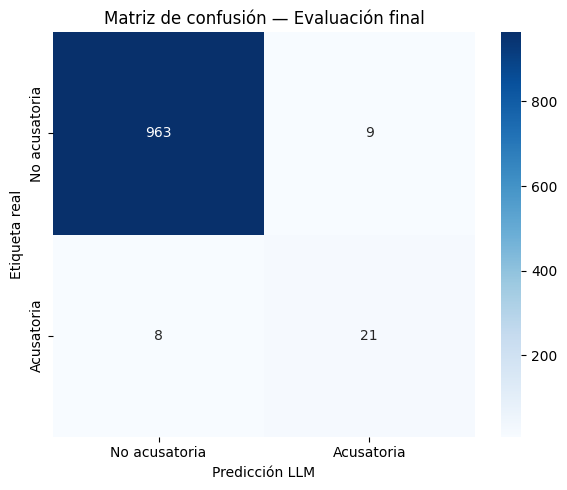

In [ ]:
FINAL_EVAL.mkdir(parents=True, exist_ok=True)
test_df = pd.read_csv(DATA_SPLITS / "test_20.csv")

# Usar prompt preconstruido con ejemplos few-shot embebidos
prompt_final_path = PROMPTS_DIR / "prompt_v17.txt"  # <-- prompt completo, ya con ejemplos
if not prompt_final_path.exists():
    raise FileNotFoundError(f'No existe el prompt final: {prompt_final_path}')

with open(prompt_final_path, encoding='utf-8') as f:
    prompt_final = f.read()

# No se calcula sample_few_shot_examples ni build_prompt, se usa el prompt tal cual
prompts_test = [prompt_final.replace('{pregunta}', q) for q in test_df['pregunta'].tolist()]

raw_test = await classify_batch(prompts_test)
test_df = test_df.copy().reset_index(drop=True)
test_df['respuesta_llm'] = raw_test
test_df['prediccion']    = [parse_response(r) for r in raw_test]

valid_test = test_df[test_df['prediccion'] != -1]
y_true_t   = valid_test['etiqueta'].values
y_pred_t   = valid_test['prediccion'].values

print("\n" + "="*60)
print("EVALUACIÓN FINAL — TEST_20")
print("="*60)
print(classification_report(y_true_t, y_pred_t, target_names=['No acusatoria', 'Acusatoria']))

# Calcular y mostrar el coeficiente de correlación de Matthews (MCC)
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_true_t, y_pred_t)

final_metrics = {
    'f1':        f1_score(y_true_t, y_pred_t, zero_division=0),
    'recall':    recall_score(y_true_t, y_pred_t, zero_division=0),
    'precision': precision_score(y_true_t, y_pred_t, zero_division=0),
    'accuracy':  accuracy_score(y_true_t, y_pred_t),
    'mcc':       mcc,
}
test_df.to_csv(FINAL_EVAL / "final_preds.csv", index=False)
test_df.to_csv(ITER_LOGS / "iter_final_preds.csv", index=False)
pd.DataFrame([final_metrics]).to_csv(FINAL_EVAL / "final_metrics.csv", index=False)
print(f"Resultados guardados en {FINAL_EVAL}")
print(f"Predicciones también en {ITER_LOGS / 'iter_final_preds.csv'}")
print(f"MCC (Matthews correlation coefficient): {mcc:.4f}")

cm = confusion_matrix(y_true_t, y_pred_t)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No acusatoria', 'Acusatoria'],
            yticklabels=['No acusatoria', 'Acusatoria'], ax=ax)
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción LLM')
ax.set_title('Matriz de confusión — Evaluación final')
plt.tight_layout()
plt.show()

## 8. Evaluación sobre test dataset externo (Roh)

Prueba el **prompt_v17** sobre el dataset externo de test completo de Roh López.
No sobreescribe los resultados de la evaluación interna.

Dataset externo: test_dataset.csv
Total preguntas : 1001
Acusatorias     : 29 (2.90%)

Prompt: prompt_v17.txt  (23596 caracteres)
Clasificando 1001 preguntas con o4-mini (reasoning_effort=medium) (0 en caché, 1001 llamadas nuevas)...


Clasificando: 100%|██████████| 1001/1001 [30:00<00:00,  1.80s/preg]


Completado: 1001 respuestas | caché en disco: 2979 entradas

EVALUACIÓN — TEST EXTERNO ROH | prompt_v17
               precision    recall  f1-score   support

No acusatoria       0.99      0.99      0.99       972
   Acusatoria       0.69      0.69      0.69        29

     accuracy                           0.98      1001
    macro avg       0.84      0.84      0.84      1001
 weighted avg       0.98      0.98      0.98      1001

MCC : 0.6804
FN  : 9  |  FP: 9

Predicciones → C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project\data\results\external_test\ext_test_preds_v17.csv
Métricas     → C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project\data\results\external_test\ext_test_metrics_v17.csv


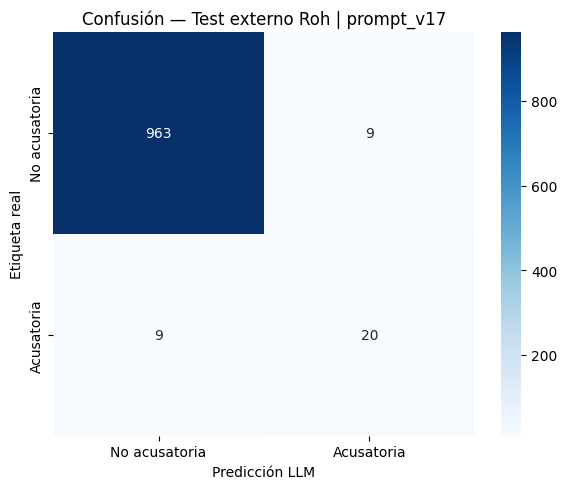

In [9]:
from sklearn.metrics import matthews_corrcoef

# ── Configuración ────────────────────────────────────────────────────────────
EXTERNAL_TEST_PATH = Path(r'C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\contexto\Trabajo_Roh\datasets\test_dataset.csv')
PROMPT_VERSION_EXT = 'v17'   # <-- cambia para probar otro prompt

# ── Carga dataset externo ─────────────────────────────────────────────────────
ext_test_df = pd.read_csv(EXTERNAL_TEST_PATH)
if 'final_pregunta_isAcusatoria' in ext_test_df.columns:
    ext_test_df = ext_test_df.rename(columns={'final_pregunta_isAcusatoria': 'etiqueta'})
ext_test_df['etiqueta'] = pd.to_numeric(ext_test_df['etiqueta'], errors='raise').astype(int)

print(f'Dataset externo: {EXTERNAL_TEST_PATH.name}')
print(f'Total preguntas : {len(ext_test_df)}')
print(f'Acusatorias     : {ext_test_df["etiqueta"].sum()} ({ext_test_df["etiqueta"].mean()*100:.2f}%)')

# ── Carga prompt ──────────────────────────────────────────────────────────────
prompt_ext_path = PROMPTS_DIR / f'prompt_{PROMPT_VERSION_EXT}.txt'
if not prompt_ext_path.exists():
    raise FileNotFoundError(f'No existe: {prompt_ext_path}')
with open(prompt_ext_path, encoding='utf-8') as f:
    prompt_ext = f.read()
print(f'\nPrompt: {prompt_ext_path.name}  ({len(prompt_ext)} caracteres)')

# ── Construir prompts (solo reemplaza {pregunta}) ─────────────────────────────
prompts_ext = [prompt_ext.replace('{pregunta}', q) for q in ext_test_df['pregunta'].tolist()]

# ── Clasificar ────────────────────────────────────────────────────────────────
raw_ext = await classify_batch(prompts_ext)
ext_test_df = ext_test_df.copy().reset_index(drop=True)
ext_test_df['respuesta_llm'] = raw_ext
ext_test_df['prediccion']    = [parse_response(r) for r in raw_ext]

invalid_ext = (ext_test_df['prediccion'] == -1).sum()
if invalid_ext:
    print(f'\nAviso: {invalid_ext} respuestas no parseables (excluidas de métricas).')

valid_ext  = ext_test_df[ext_test_df['prediccion'] != -1].copy()
y_true_ext = valid_ext['etiqueta'].values
y_pred_ext = valid_ext['prediccion'].values

# ── Métricas ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f'EVALUACIÓN — TEST EXTERNO ROH | prompt_{PROMPT_VERSION_EXT}')
print("="*60)
print(classification_report(y_true_ext, y_pred_ext, target_names=['No acusatoria', 'Acusatoria']))

mcc_ext = matthews_corrcoef(y_true_ext, y_pred_ext)
metrics_ext = {
    'prompt':    f'prompt_{PROMPT_VERSION_EXT}',
    'f1':        f1_score(y_true_ext, y_pred_ext, zero_division=0),
    'recall':    recall_score(y_true_ext, y_pred_ext, zero_division=0),
    'precision': precision_score(y_true_ext, y_pred_ext, zero_division=0),
    'accuracy':  accuracy_score(y_true_ext, y_pred_ext),
    'mcc':       mcc_ext,
    'fn':        int(((y_true_ext == 1) & (y_pred_ext == 0)).sum()),
    'fp':        int(((y_true_ext == 0) & (y_pred_ext == 1)).sum()),
    'n_total':   len(ext_test_df),
    'n_valid':   len(valid_ext),
    'n_invalid': int(invalid_ext),
}
print(f'MCC : {mcc_ext:.4f}')
print(f'FN  : {metrics_ext["fn"]}  |  FP: {metrics_ext["fp"]}')

# ── Guardar resultados ────────────────────────────────────────────────────────
OUT_DIR = DATA_RESULTS / 'external_test'
OUT_DIR.mkdir(parents=True, exist_ok=True)

preds_out   = OUT_DIR / f'ext_test_preds_{PROMPT_VERSION_EXT}.csv'
metrics_out = OUT_DIR / f'ext_test_metrics_{PROMPT_VERSION_EXT}.csv'
ext_test_df.to_csv(preds_out, index=False)
pd.DataFrame([metrics_ext]).to_csv(metrics_out, index=False)
print(f'\nPredicciones → {preds_out}')
print(f'Métricas     → {metrics_out}')

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No acusatoria', 'Acusatoria'],
            yticklabels=['No acusatoria', 'Acusatoria'], ax=ax)
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción LLM')
ax.set_title(f'Confusión — Test externo Roh | prompt_{PROMPT_VERSION_EXT}')
plt.tight_layout()
plt.show()


Total Roh test        : 1001
Excluidos (en train_80): 786
Evaluables limpios    : 215

=== Roh test COMPLETO (1001) (n=1001) ===
               precision    recall  f1-score   support

No acusatoria       0.99      0.99      0.99       972
   Acusatoria       0.69      0.69      0.69        29

     accuracy                           0.98      1001
    macro avg       0.84      0.84      0.84      1001
 weighted avg       0.98      0.98      0.98      1001

MCC : 0.6804
FN  : 9  |  FP: 9

=== Roh test LIMPIO sin train_80 (216) (n=215) ===
               precision    recall  f1-score   support

No acusatoria       1.00      0.99      0.99       210
   Acusatoria       0.67      0.80      0.73         5

     accuracy                           0.99       215
    macro avg       0.83      0.90      0.86       215
 weighted avg       0.99      0.99      0.99       215

MCC : 0.7233
FN  : 1  |  FP: 2

Guardado en C:\Users\martin\Documents\proyecto_integrador\entregable_2-3\llm_judge_project

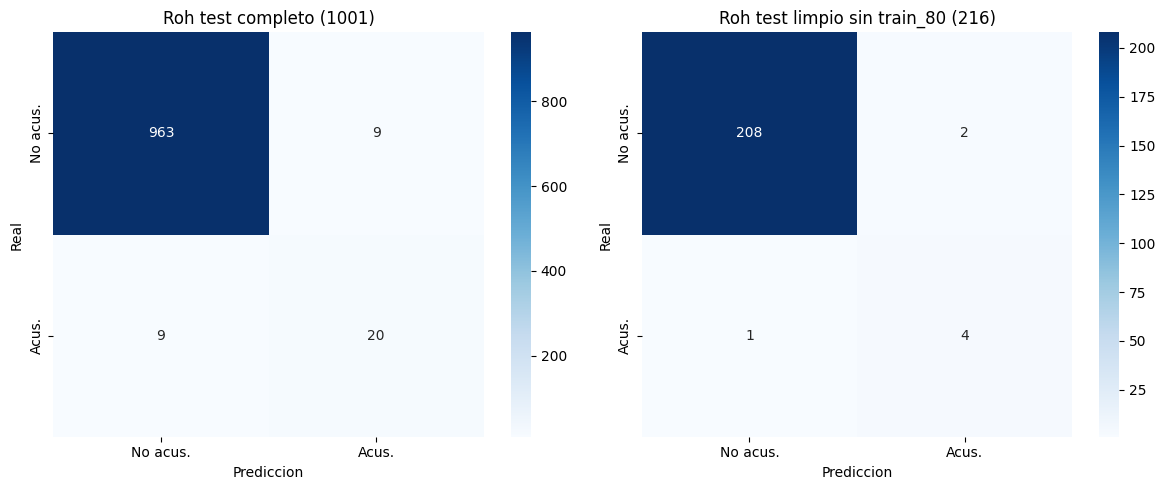

In [18]:
# ── Métricas Roh filtradas: excluir ejemplos que estuvieron en train_80 ─────
# No requiere re-correr el modelo. Filtra ext_test_preds_v17.csv ya generado.

from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score,
                             accuracy_score, matthews_corrcoef)

preds_path = DATA_RESULTS / 'external_test' / 'ext_test_preds_v17.csv'
ext_preds  = pd.read_csv(preds_path)

# IDs que estuvieron en nuestro train_80 (vistas durante desarrollo del prompt)
train_80_ids = set(pd.read_csv(DATA_SPLITS / 'train_80.csv')['pregunta_id'])

mask_clean  = ~ext_preds['pregunta_id'].isin(train_80_ids)
ext_clean   = ext_preds[mask_clean & (ext_preds['prediccion'] != -1)].copy()
ext_all_val = ext_preds[ext_preds['prediccion'] != -1].copy()

print(f'Total Roh test        : {len(ext_preds)}')
print(f'Excluidos (en train_80): {(~mask_clean).sum()}')
print(f'Evaluables limpios    : {len(ext_clean)}')
print()

def report_metrics(df, label):
    y_true = df['etiqueta'].values
    y_pred = df['prediccion'].values
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f'=== {label} (n={len(df)}) ===')
    print(classification_report(y_true, y_pred, target_names=['No acusatoria', 'Acusatoria']))
    print(f'MCC : {mcc:.4f}')
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    print(f'FN  : {fn}  |  FP: {fp}')
    print()
    return {'n': len(df), 'f1': f1_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'accuracy': accuracy_score(y_true, y_pred), 'mcc': mcc, 'fn': fn, 'fp': fp}

m_all   = report_metrics(ext_all_val,  'Roh test COMPLETO (1001)')
m_clean = report_metrics(ext_clean,    'Roh test LIMPIO sin train_80 (216)')

# Guardar métricas limpias
out = DATA_RESULTS / 'external_test' / 'ext_test_metrics_v17_clean.csv'
pd.DataFrame([{'subset': 'completo', **m_all}, {'subset': 'limpio_sin_train80', **m_clean}]).to_csv(out, index=False)
print(f'Guardado en {out}')

# Matrices de confusion lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, title in zip(axes,
                          [ext_all_val, ext_clean],
                          ['Roh test completo (1001)', 'Roh test limpio sin train_80 (216)']):
    cm = confusion_matrix(df['etiqueta'], df['prediccion'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No acus.', 'Acus.'],
                yticklabels=['No acus.', 'Acus.'], ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Real')
    ax.set_xlabel('Prediccion')
plt.tight_layout()
plt.show()
